# 3. Windowed Dual-network INR：全局网络、窗口物理优化

网络、全局时间坐标和优化器状态在49个时刻上始终保持不变；window 只限制每次参与 ERT 正演/VJP 的时刻。窗口重叠权重用于抵消中部时刻被重复采样，并定期用完整49时刻计算公平的全局 χ²。

输出目录：`result/2_inversion/0_flat_model/3`。


## 1. 环境与 GPU 检查


In [1]:
from pathlib import Path
import json
import os
import sys

os.environ.setdefault('ADTLERT_ENABLE_FLOAT64', '1')

cwd = Path.cwd().resolve()
root = next(path for path in (cwd, *cwd.parents) if (path / 'pyproject.toml').exists())
sys.path.insert(0, str(root))

import matplotlib.pyplot as plt
import numpy as np
import torch


torch.set_default_dtype(torch.float64)  # after adtlert fixed FLOAT_DTYPE at import
torch.set_float32_matmul_precision('high')

from adtlert.inr import INRConfig, fit_timelapse_inr
from example.timelapse_inr_experiment import (
    INRSnapshotRecorder,
    build_inr_forward,
    load_flat_timelapse_data,
    make_global_coordinates,
    plot_inr_recovery,
    save_inr_result,
)

forward_dir = root / 'result/1_forward/0_flat_model'
truth_dir = root / 'data/test_model/0_flat_model'
assert torch.cuda.is_available(), '本 notebook 强制要求 CUDA，但 torch.cuda.is_available() 为 False'
print('project root:', root)
print('GPU:', torch.cuda.get_device_name(torch.cuda.current_device()))


project root: /home/luffy/projects/DeepERT
GPU: NVIDIA GeForce RTX 5060 Laptop GPU


## 2. 固定实验设置

三种 INR 共用相同网格、误差模型、初始电阻率、边界、初始学习率 `1e-3` 和最多 1000 轮优化；停止条件关闭。每 100 轮保存一次完整时移电阻率快照。不同策略的单轮计算量可以不同，运行时间仅作为实际计算成本参考。


In [2]:
method_label = 'Windowed Dual-network INR'
output_dir = root / 'result/2_inversion/0_flat_model/3'
output_dir.mkdir(parents=True, exist_ok=True)

settings = {
    'random_seed': 20261001,
    'max_iterations': 1000,
    'learning_rate': 1.0e-3,
    'optimizer': 'adamw',
    'scheduler': 'multistep',
    'learning_rate_milestones': (400, 750),
    'weight_decay': 1.0e-6,
    'progressive_full_iteration': 200,
    'snapshot_interval': 100,
    'time_window_size': 7,
    'time_window_step': 3,
    'full_evaluation_interval': 20,
    'mesh_quality': 34.0,
    'mesh_max_cell_area': 100.0,
    'mesh_smoothing_iterations': 10,
    'forward_refinement': 'native',
    'normal_field_cache_max_entries': 8,
}
print('output:', output_dir)
settings


output: /home/luffy/projects/DeepERT/result/2_inversion/0_flat_model/3


{'random_seed': 20261001,
 'max_iterations': 1000,
 'learning_rate': 0.001,
 'optimizer': 'adamw',
 'scheduler': 'multistep',
 'learning_rate_milestones': (400, 750),
 'weight_decay': 1e-06,
 'progressive_full_iteration': 200,
 'snapshot_interval': 100,
 'time_window_size': 7,
 'time_window_step': 3,
 'full_evaluation_interval': 20,
 'mesh_quality': 34.0,
 'mesh_max_cell_area': 100.0,
 'mesh_smoothing_iterations': 10,
 'forward_refinement': 'native',
 'linear_solver_backend': 'cudss',
 'normal_field_cache_max_entries': 8}

## 3. 读取49个时刻的 DAT 观测与合成真值


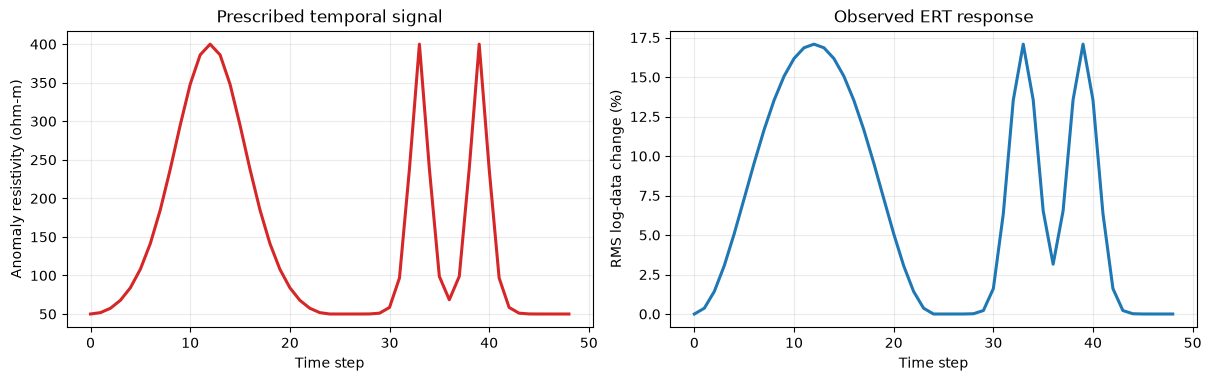

timesteps: 49
observed rhoa: (49, 360)
measurements per timestep: 360
median relative error: 0.03


In [3]:
data = load_flat_timelapse_data(forward_dir, truth_dir)
log_change_rms = 100.0 * np.sqrt(
    np.mean(np.log(data.observed_rhoa / data.observed_rhoa[0]) ** 2, axis=1)
)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.7), constrained_layout=True)
axes[0].plot(data.steps, data.truth_anomaly_curve, color='#d62728', linewidth=2.2)
axes[0].set(xlabel='Time step', ylabel='Anomaly resistivity (ohm-m)', title='Prescribed temporal signal')
axes[0].grid(alpha=0.25)
axes[1].plot(data.steps, log_change_rms, color='#1f77b4', linewidth=2.2)
axes[1].set(xlabel='Time step', ylabel='RMS log-data change (%)', title='Observed ERT response')
axes[1].grid(alpha=0.25)
plt.show()

print('timesteps:', data.steps.size)
print('observed rhoa:', data.observed_rhoa.shape)
print('measurements per timestep:', data.measurements.shape[0])
print('median relative error:', float(np.median(data.err)))


## 4. 建立独立反演网格与全局 `(x,z,t)` 坐标

反演参数网格仅由电极与测量装置生成，不使用合成真值的规则网格。时间始终按完整49时刻归一化。


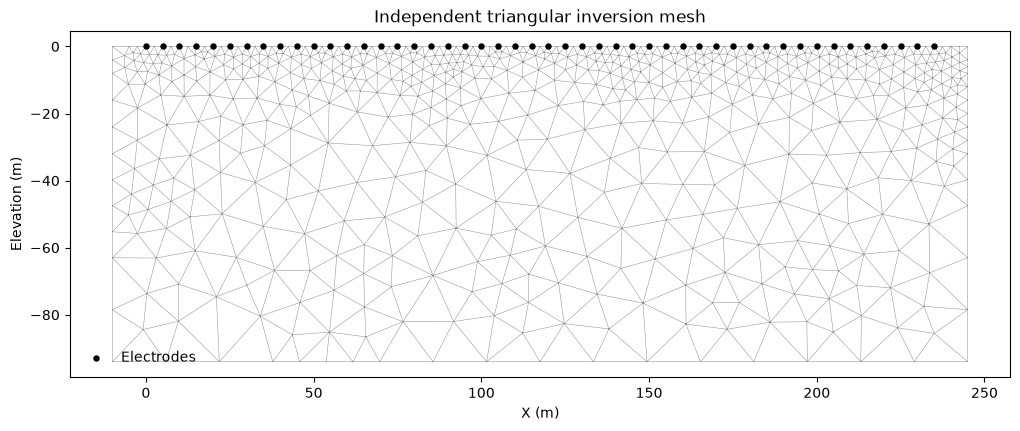

coordinates: (49, 1126, 3) range: -1.0 to 1.0
inversion cells: 1126
forward cells: 1768
truth-grid cells: 2256


In [4]:
bundle = build_inr_forward(
    data,
    mesh_quality=settings['mesh_quality'],
    mesh_max_cell_area=settings['mesh_max_cell_area'],
    mesh_smoothing_iterations=settings['mesh_smoothing_iterations'],
    forward_refinement=settings['forward_refinement'],
    normal_field_cache_max_entries=settings['normal_field_cache_max_entries'],
)
coordinates, coordinate_center, coordinate_scale = make_global_coordinates(bundle, data.steps)

mesh_nodes = np.asarray(bundle.case.mesh.nodes, dtype=float)
mesh_cells = np.asarray(bundle.case.mesh.cells, dtype=np.int32)
fig, ax = plt.subplots(figsize=(12, 4.2), constrained_layout=True)
ax.triplot(mesh_nodes[:, 0], mesh_nodes[:, 1], mesh_cells, color='0.55', linewidth=0.35)
ax.scatter(data.elec_x, data.elec_z, s=13, c='black', zorder=3, label='Electrodes')
ax.set(xlabel='X (m)', ylabel='Elevation (m)', title='Independent triangular inversion mesh')
ax.set_aspect('equal', adjustable='box')
ax.legend(frameon=False)
plt.show()

print('coordinates:', coordinates.shape, 'range:', float(coordinates.min()), 'to', float(coordinates.max()))
print('inversion cells:', bundle.case.mesh.cell_count)
print('forward cells:', bundle.forward_mesh.cell_count)
print('truth-grid cells:', data.truth_models.shape[1] * data.truth_models.shape[2])


## 5. 构建 INR

网络输出有界的对数电阻率，并通过零初始化输出层严格从100 Ω·m均匀模型开始。


In [5]:
from adtlert.inr import DualNetworkINR

torch.manual_seed(settings['random_seed'])
network = DualNetworkINR(
    spatial_levels=5,
    temporal_levels=4,
    spatial_hidden_width=64,
    temporal_hidden_width=32,
    spatial_hidden_layers=3,
    temporal_hidden_layers=2,
    initial_resistivity=100.0,
    resistivity_bounds=(10.0, 1000.0),
)

parameter_count = sum(parameter.numel() for parameter in network.parameters())
with torch.no_grad():
    initial_log_model = network.to(device='cuda', dtype=torch.float32)(torch.as_tensor(coordinates, device='cuda'))
initial_rho = initial_log_model.exp()
assert torch.allclose(initial_rho, torch.full_like(initial_rho, 100.0), atol=1.0e-3)
print(type(network).__name__)
print('trainable parameters:', parameter_count)
print('initial resistivity:', float(initial_rho.min()), 'to', float(initial_rho.max()), 'ohm-m')
del initial_log_model, initial_rho


DualNetworkINR
trainable parameters: 11266
initial resistivity: 100.0 to 100.0 ohm-m


## 6. 配置进度输出与模型快照


In [6]:
snapshot_recorder = INRSnapshotRecorder(output_dir / 'snapshots')

def report_progress(event):
    snapshot_path = snapshot_recorder(event)
    if snapshot_path is not None:
        print(f'saved snapshot: {snapshot_path.name}')
        return
    if event.get('event') != 'iteration':
        return
    full_text = '' if event.get('full_chi2') is None else f", full chi2={event['full_chi2']:.6g}"
    window_text = '' if event.get('window_start') is None else f", window=[{event['window_start']}:{event['window_stop']}]"
    print(
        f"iter={event['iteration']:4d}, train chi2={event['chi2']:.6g}{full_text}{window_text}, "
        f"lr={event['learning_rate']:.3g}"
    )


## 7. GPU ERT 物理约束反演

网络在 CUDA 上运行；ERT 线性求解器必须实际启用 cuDSS，否则立即报错。


In [7]:
config = INRConfig(
    max_iterations=settings['max_iterations'],
    learning_rate=settings['learning_rate'],
    optimizer=settings['optimizer'],
    scheduler=settings['scheduler'],
    learning_rate_milestones=settings['learning_rate_milestones'],
    target_chi2=None,
    device='cuda',
    gradient_clip_norm=10.0,
    weight_decay=settings['weight_decay'],
    progressive_encoding=True,
    progressive_full_iteration=settings['progressive_full_iteration'],
    progressive_spatial_start_levels=2,
    progressive_temporal_start_levels=1,
    spatial_regularization=0.0,
    temporal_regularization=0.0,
    log_every=10,
    prepare_solver=True,
    time_window_size=settings['time_window_size'],
    time_window_step=settings['time_window_step'],
    full_evaluation_interval=settings['full_evaluation_interval'],
    alternate_window_direction=True,
    snapshot_interval=settings['snapshot_interval'],
    progress_callback=report_progress,
)

try:
    result = fit_timelapse_inr(
        bundle.forward,
        network,
        coordinates,
        data.observed_rhoa,
        data.data_std,
        config=config,
    )
finally:
    bundle.forward.close()

print(json.dumps(result.gpu_report, indent=2))
print(f'best iter={result.best_iteration}, chi2={result.best_chi2:.6g}')
print(f'time={result.elapsed_seconds:.3f} s, stop={result.stop_reason}')
print('physics forward/VJP timesteps:', result.physics_forward_timesteps, result.physics_vjp_timesteps)


iter=   0, train chi2=2.87707, full chi2=4.79141, window=[0:7], lr=0.001
iter=  10, train chi2=3.69579, window=[30:37], lr=0.001
iter=  20, train chi2=4.95924, full chi2=4.76148, window=[27:34], lr=0.001
iter=  30, train chi2=3.12776, window=[0:7], lr=0.001
iter=  40, train chi2=3.65269, full chi2=4.69824, window=[30:37], lr=0.001
iter=  50, train chi2=4.9817, window=[27:34], lr=0.001
iter=  60, train chi2=3.87677, full chi2=4.6051, window=[0:7], lr=0.001
iter=  70, train chi2=3.70624, window=[30:37], lr=0.001
iter=  80, train chi2=4.81121, full chi2=4.45689, window=[27:34], lr=0.001
iter=  90, train chi2=5.93878, window=[0:7], lr=0.001
iter= 100, train chi2=3.89652, full chi2=4.31475, window=[30:37], lr=0.001
saved snapshot: resistivity_iter_0100.npy
iter= 110, train chi2=4.48246, window=[27:34], lr=0.001
iter= 120, train chi2=8.47811, full chi2=4.22821, window=[0:7], lr=0.001
iter= 130, train chi2=4.13229, window=[30:37], lr=0.001
iter= 140, train chi2=3.94491, full chi2=4.09577, win

## 8. 保存统一格式结果与快照索引


In [8]:
summary = save_inr_result(
    output_dir,
    method=method_label,
    data=data,
    bundle=bundle,
    network=network,
    config=config,
    result=result,
    coordinate_center=coordinate_center,
    coordinate_scale=coordinate_scale,
)
snapshot_recorder.save_summary()
summary


{'engine': 'ADTLERT matrix-free GPU INR',
 'method': 'Windowed Dual-network INR',
 'network_class': 'DualNetworkINR',
 'network_configuration': {'spatial_levels': 5,
  'temporal_levels': 4,
  'spatial_hidden_width': 64,
  'temporal_hidden_width': 32,
  'spatial_hidden_layers': 3,
  'temporal_hidden_layers': 2,
  'initial_resistivity': 100.0,
  'resistivity_bounds': (10.0, 1000.0),
  'frequency_spacing': 'log_uniform'},
 'network_parameter_count': 11266,
 'n_timesteps': 49,
 'n_measurements_per_timestep': 360,
 'n_inversion_cells': 1126,
 'n_forward_cells': 1768,
 'mesh_is_independent_from_synthetic_grid': True,
 'initial_resistivity_ohm_m': 100.0,
 'explicit_spatial_regularization': 0.0,
 'explicit_temporal_regularization': 0.0,
 'config': {'max_iterations': 1000,
  'learning_rate': 0.001,
  'optimizer': 'adamw',
  'scheduler': 'multistep',
  'learning_rate_milestones': (400, 750),
  'target_chi2': None,
  'device': 'cuda',
  'require_cuda': True,
  'gradient_clip_norm': 10.0,
  'weigh

## 9. 查看优化过程


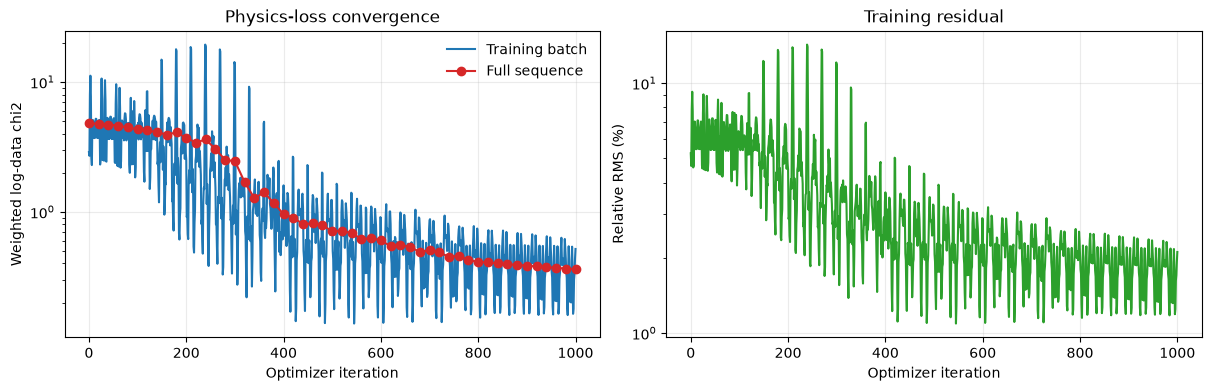

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), constrained_layout=True)
axes[0].plot(np.arange(result.chi2_history.size), result.chi2_history, color='#1f77b4', label='Training batch')
axes[0].plot(result.full_chi2_iterations, result.full_chi2_history, 'o-', color='#d62728', label='Full sequence')
axes[0].set(xlabel='Optimizer iteration', ylabel='Weighted log-data chi2', title='Physics-loss convergence')
axes[0].set_yscale('log')
axes[0].grid(alpha=0.25)
axes[0].legend(frameon=False)
axes[1].plot(np.arange(result.rms_history.size), result.rms_history, color='#2ca02c')
axes[1].set(xlabel='Optimizer iteration', ylabel='Relative RMS (%)', title='Training residual')
axes[1].set_yscale('log')
axes[1].grid(alpha=0.25)
plt.show()


## 10. 真值、反演快照与异常体时间曲线

所有方法固定使用30–600 Ω·m色标以及相同的六个时刻。


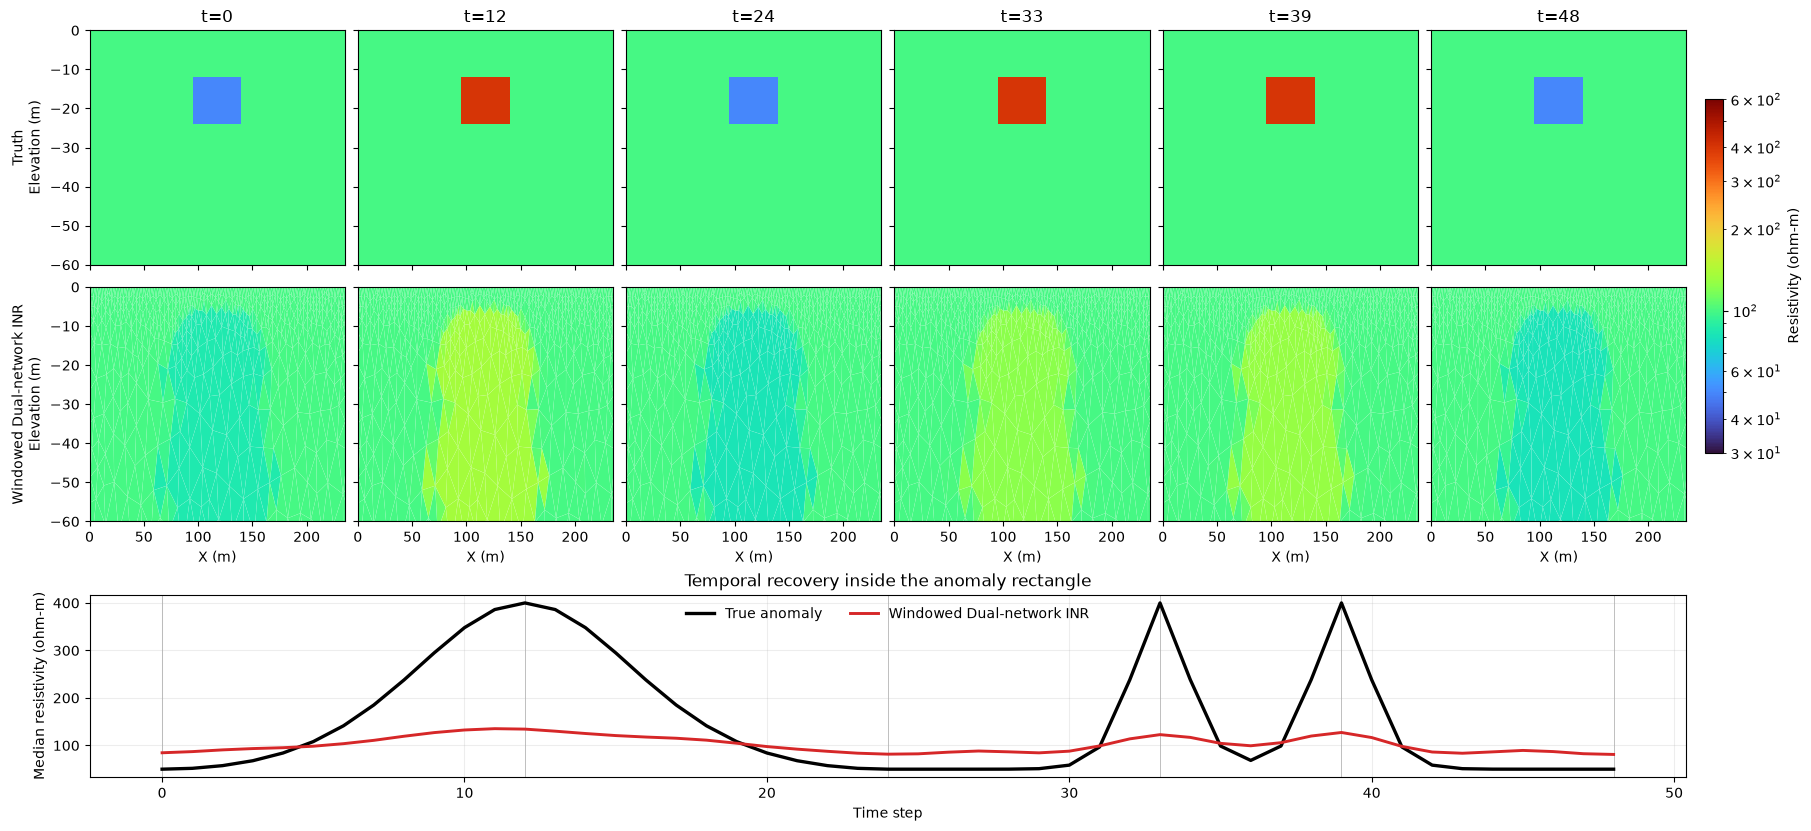

In [10]:
inverted_anomaly_curve = plot_inr_recovery(
    output_dir,
    method_label=method_label,
    data=data,
    bundle=bundle,
    result=result,
)


## 11. 输出文件


In [11]:
for path in sorted(output_dir.iterdir()):
    print(f'{path.name:36s} {path.stat().st_size:>12d} bytes')


chi2_by_time.npy                              520 bytes
coordinate_transform.npz                      414 bytes
final_log_models.npy                       441520 bytes
final_models.npy                           441520 bytes
inversion_summary.json                       2302 bytes
model_and_temporal_recovery.png           1058552 bytes
network.pt                                  53845 bytes
predicted_rhoa.npy                         141248 bytes
snapshots                                    4096 bytes
steps.npy                                     324 bytes
timelapse_inversion_mesh.npz               115920 bytes
training_history.npz                        14662 bytes
used_data_files.txt                          4802 bytes
